# Notebook 2 — Threshold Analysis & Derivation

## Purpose
This notebook **derives and justifies every preprocessing threshold** from
train+val signal statistics. The test set is never used.

| Threshold | What it controls |
|---|---|
| `STILL_MEAN = 1.25g` | Post-fall acc mean must be below this to confirm stillness |
| `MIN_STILL = 150 samples` | Minimum duration of post-fall stillness (1.5s at 100Hz) |
| `POST_STILL_MAX = 1.6g` | Max acc after stillness — rejects resumed-activity trials |
| `FALL_PRE = FALL_POST = 25` | Window size: ±250ms around impact = 500ms total |
| `HARD_THRESH` | 75th percentile of ADL peaks — selects hard negative windows |
| `EASY_THRESH` | 25th percentile of ADL peaks — selects easy negative windows |
| Per-type thresholds | Per-fall-type acc and gyro detection thresholds |

> **STILL_STD was evaluated and removed.** It covered only 1.6% of post-fall regions.
> Removing it lost only 4 detections (98.9% → 98.7%). STILL_MEAN alone is simpler and sufficient.

**Output:** `analysis_output.json` → loaded by all 4 experiment notebooks.

---
## Requirements
```
scikit-learn>=1.2.0  numpy>=1.23.0  matplotlib>=3.6.0
```


## Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 2 — Install dependencies

In [2]:
!pip install scikit-learn -q
print('Done')

Done


## Cell 3 — Configuration

In [4]:
import os
import json
import random
import numpy as np
from sklearn.model_selection import train_test_split
from collections import defaultdict
import glob
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────────────
DATASET_DIR   = '/content/drive/MyDrive/M4/Data_Collected'
SPLIT_PATH    = '/content/drive/MyDrive/M4/01.npz'
ANALYSIS_JSON = '/content/drive/MyDrive/M4/02_analysis.json'

# ── Windowing parameters ───────────────────────────────────────────────
WIN_SAMPLES = 50    # 500 ms at 100 Hz
STRIDE      = 20    # 200 ms stride (60% overlap)

# ── Split parameters ───────────────────────────────────────────────────
RANDOM_SEED = 42
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ── Volunteer lists ────────────────────────────────────────────────────
# V1–V8, V10 : all performed falls AND ADLs
# No elderly-only group (unlike SisFall SE01–SE15)
ALL_VOLUNTEERS = [
    'V1_Sama', 'V2_Shams', 'V3_Mary', 'V4_Yasamin',
    'V5_Betty', 'V6_Jannah', 'V7_Warda', 'V8_Ismat',
    'V10_Isham'
]

# ── Activity codes — auto-detected from filenames ──────────────────────
_all_csvs  = glob.glob(os.path.join(DATASET_DIR, '**', '*.csv'), recursive=True)
FALL_CODES = sorted(set(
    os.path.basename(f)[:3] for f in _all_csvs
    if os.path.basename(f)[0].upper() == 'F'
))
ADL_CODES  = sorted(set(
    os.path.basename(f)[:3] for f in _all_csvs
    if os.path.basename(f)[0].upper() == 'D'
))

# ── EXCLUDE — files with no detectable impact or parse errors ──────────
EXCLUDE = {
    'V1_Sama/D11_01.csv', 'V1_Sama/F04_05.csv',
    'V1_Sama/D07_03.csv', 'V1_Sama/D17_01.csv',
    'V1_Sama/D02_01.csv', 'V1_Sama/F01_01.csv',
    'V10_Isham/F01_01.csv', 'V10_Isham/F01_02.csv', 'V10_Isham/F01_03.csv',
    'V10_Isham/F02_02.csv', 'V10_Isham/F03_02.csv', 'V10_Isham/F03_03.csv',
    'V10_Isham/F03_04.csv', 'V10_Isham/F04_01.csv', 'V10_Isham/F06_01.csv',
    'V10_Isham/F09_01.csv',
    'V2_Shams/F02_01.csv', 'V2_Shams/F03_02.csv',
    'V2_Shams/F07_01.csv', 'V2_Shams/F14_01.csv',
    'V3_Mary/F02_01.csv',  'V3_Mary/F02_02.csv',
    'V3_Mary/F03_01.csv',  'V3_Mary/F03_02.csv',
    'V4_Yasamin/F01_01.csv', 'V4_Yasamin/F03_01.csv',
    'V5_Betty/F03_01.csv',   'V5_Betty/F11_01.csv',
    'V6_Jannah/F05_01.csv',  'V6_Jannah/F06_01.csv',
    'V6_Jannah/F07_01.csv',  'V6_Jannah/F09_01.csv',
    'V6_Jannah/F12_01.csv',
    'V7_Warda/F01_01.csv',  'V7_Warda/F01_03.csv',
    'V7_Warda/F04_01.csv',  'V7_Warda/F05_01.csv',
    'V7_Warda/F06_01.csv',  'V7_Warda/F07_01.csv',
    'V7_Warda/F09_01.csv',  'V7_Warda/F12_01.csv',
}

# ── No sensor scaling needed ───────────────────────────────────────────
# SisFall needed: MMA_SCALE = (2×8)/2^14, ITG_SCALE = (2×2000)/2^16
# Your data is already in physical units (g and dps) — no conversion
TRIM_SAMPLES = 100   # rows trimmed from start/end of each file

print('Configuration set')
print(f'  Volunteers : {len(ALL_VOLUNTEERS)}')
print(f'  Fall codes : {len(FALL_CODES)} → {FALL_CODES}')
print(f'  ADL codes  : {len(ADL_CODES)}  → {ADL_CODES}')
print(f'  Excluded   : {len(EXCLUDE)} files')

Configuration set
  Volunteers : 9
  Fall codes : 16 → ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'fal']
  ADL codes  : 19  → ['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19']
  Excluded   : 41 files


## Cell 4 — Helper functions
Same helpers as Notebook 1. `smv()` is used throughout the analysis.

In [5]:
def load_trial(filepath):
    """
    Read one collected CSV file and return physical-unit sensor data.
    Files are already cleaned with header: t_ms,ax_g,ay_g,az_g,gx_dps,gy_dps,gz_dps
    Data is already in physical units (g and dps) — no scaling needed.
    First and last TRIM_SAMPLES rows are removed to avoid recording artifacts.

    Returns:
      accel [N, 3] in g    (ax_g, ay_g, az_g)
      gyro  [N, 3] in dps  (gx_dps, gy_dps, gz_dps)
      Returns (None, None) if file has fewer than WIN_SAMPLES rows.
    """
    cols = ['t_ms','ax_g','ay_g','az_g','gx_dps','gy_dps','gz_dps']

    header_line = None
    with open(filepath, 'rb') as f:
        for i, line in enumerate(f):
            if line.strip().startswith(b't_ms'):
                header_line = i; break
    if header_line is None:
        return None, None

    try:
        df = pd.read_csv(filepath, skiprows=header_line, on_bad_lines='skip')
        for c in cols:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        df = df.dropna(subset=cols)[['ax_g','ay_g','az_g','gx_dps','gy_dps','gz_dps']]
    except Exception as e:
        print(f'  Parse error {filepath}: {e}')
        return None, None

    df = df.iloc[TRIM_SAMPLES:-TRIM_SAMPLES]
    if len(df) < WIN_SAMPLES:
        return None, None

    accel = df[['ax_g','ay_g','az_g']].values.astype(np.float32)
    gyro  = df[['gx_dps','gy_dps','gz_dps']].values.astype(np.float32)
    return accel, gyro


def downsample(signal):
    """
    NOT needed for collected data — pass-through only.
    Arduino LSM9DS1 is configured natively at 100 Hz.
    SisFall was recorded at 200 Hz and needed [::2] decimation.
    Kept for API compatibility with the rest of the pipeline.
    """
    return signal.astype(np.float32)


def smv(a):
    """Signal Magnitude Vector: sqrt(x² + y² + z²) per sample."""
    return np.sqrt(np.sum(a ** 2, axis=1))


print('Helper functions defined')

Helper functions defined


## Cell 5 — Load train+val split from Notebook 1

Loads the split saved by Notebook 1. Only train+val trials are used for analysis.
The test split is loaded into variables but **never accessed below**.


In [8]:
print('Loading split from Notebook 1...')
data = np.load(SPLIT_PATH, allow_pickle=True)

def unpack_trials(data, prefix):
    """Reconstruct trial dicts from packed NPZ arrays."""
    accels     = data[f'{prefix}_accels']
    gyros      = data[f'{prefix}_gyros']
    volunteers = data[f'{prefix}_volunteers']
    codes      = data[f'{prefix}_codes']
    trials = []
    for a, g, v, c in zip(accels, gyros, volunteers, codes):
        trials.append({
            'volunteer':     str(v),
            'activity_code': str(c),
            'is_fall':       str(c) in FALL_CODES,
            'accel_ds':      np.array(a, dtype=np.float32),
            'gyro_ds':       np.array(g, dtype=np.float32),
            'a_smv':         smv(np.array(a, dtype=np.float32)),
            'g_smv':         smv(np.array(g, dtype=np.float32)),
        })
    return trials

fall_train = unpack_trials(data, 'fall_train')
fall_val   = unpack_trials(data, 'fall_val')
fall_test  = unpack_trials(data, 'fall_test')   # loaded but NEVER used below
adl_train  = unpack_trials(data, 'adl_train')
adl_val    = unpack_trials(data, 'adl_val')
adl_test   = unpack_trials(data, 'adl_test')    # loaded but NEVER used below

# Analysis pool = train + val only
design_falls = fall_train + fall_val
design_adls  = adl_train  + adl_val

print(f'Fall train+val : {len(design_falls)}  |  ADL train+val : {len(design_adls)}')
print(f'Fall test      : {len(fall_test)}   (LOCKED — not used in this notebook)')
print(f'ADL test       : {len(adl_test)}   (LOCKED — not used in this notebook)')

Loading split from Notebook 1...
Fall train+val : 94  |  ADL train+val : 152
Fall test      : 17   (LOCKED — not used in this notebook)
ADL test       : 27   (LOCKED — not used in this notebook)


## Cell 6 — Compute signal statistics from train+val falls

For each fall trial in train+val, we scan the signal after the impact peak to find
the post-fall stillness region. We record:
- **post_still_means**: mean acc in the stillness region → used to set STILL_MEAN
- **still_durations**: how many samples the stillness lasts → used to set MIN_STILL
- **fall_peak_accs**: acc SMV peak per fall type → used for per-type thresholds
- **fall_peak_gyrs**: gyro SMV peak per fall type → used for per-type thresholds


In [9]:
print('Computing signal statistics from train+val falls...')

post_still_means = []
still_durations  = []
fall_peak_accs   = defaultdict(list)
fall_peak_gyrs   = defaultdict(list)

for trial in design_falls:
    a    = trial['a_smv']
    g    = trial['g_smv']
    n    = len(a)
    code = trial['activity_code']

    # ── Find impact peak ───────────────────────────────────────────────
    pk = int(np.argmax(a))
    fall_peak_accs[code].append(float(a[pk]))

    # Gyro peak within ±1s of impact
    gs = max(0, pk - 100); ge = min(n, pk + 100)
    fall_peak_gyrs[code].append(float(g[gs:ge].max()))

    # ── Scan for post-fall stillness (loose scan at 1.5g) ─────────────
    # We use a loose scan threshold here just to find the region;
    # the actual STILL_MEAN threshold is derived from what we find.
    for i in range(pk + 1, n - 150):
        r = a[i:i + 150]
        if r.mean() < 1.5:
            post_still_means.append(float(r.mean()))
            still_durations.append(n - i)
            break

# ── ADL window peak distribution ──────────────────────────────────────
adl_window_peaks = []
for trial in design_adls:
    a = trial['a_smv']; n = len(a)
    for w in range(0, n - WIN_SAMPLES + 1, STRIDE):
        adl_window_peaks.append(float(a[w:w + WIN_SAMPLES].max()))

post_still_means = np.array(post_still_means)
still_durations  = np.array(still_durations)
adl_window_peaks = np.array(adl_window_peaks)

print(f'Post-fall regions found : {len(post_still_means):,}')
print(f'ADL windows collected   : {len(adl_window_peaks):,}')


Computing signal statistics from train+val falls...
Post-fall regions found : 90
ADL windows collected   : 25,330


## Cell 7 — Plot 1: Fall SMV profiles per type

**Justifies `FALL_PRE = FALL_POST = 25 samples (±250ms = 500ms total)`**

Each panel shows the average acc SMV profile centred on the impact peak for one fall type.
Green dashed lines mark our ±250ms window boundary. If the impact event fits within the
green lines for all fall types, the 500ms window is sufficient.


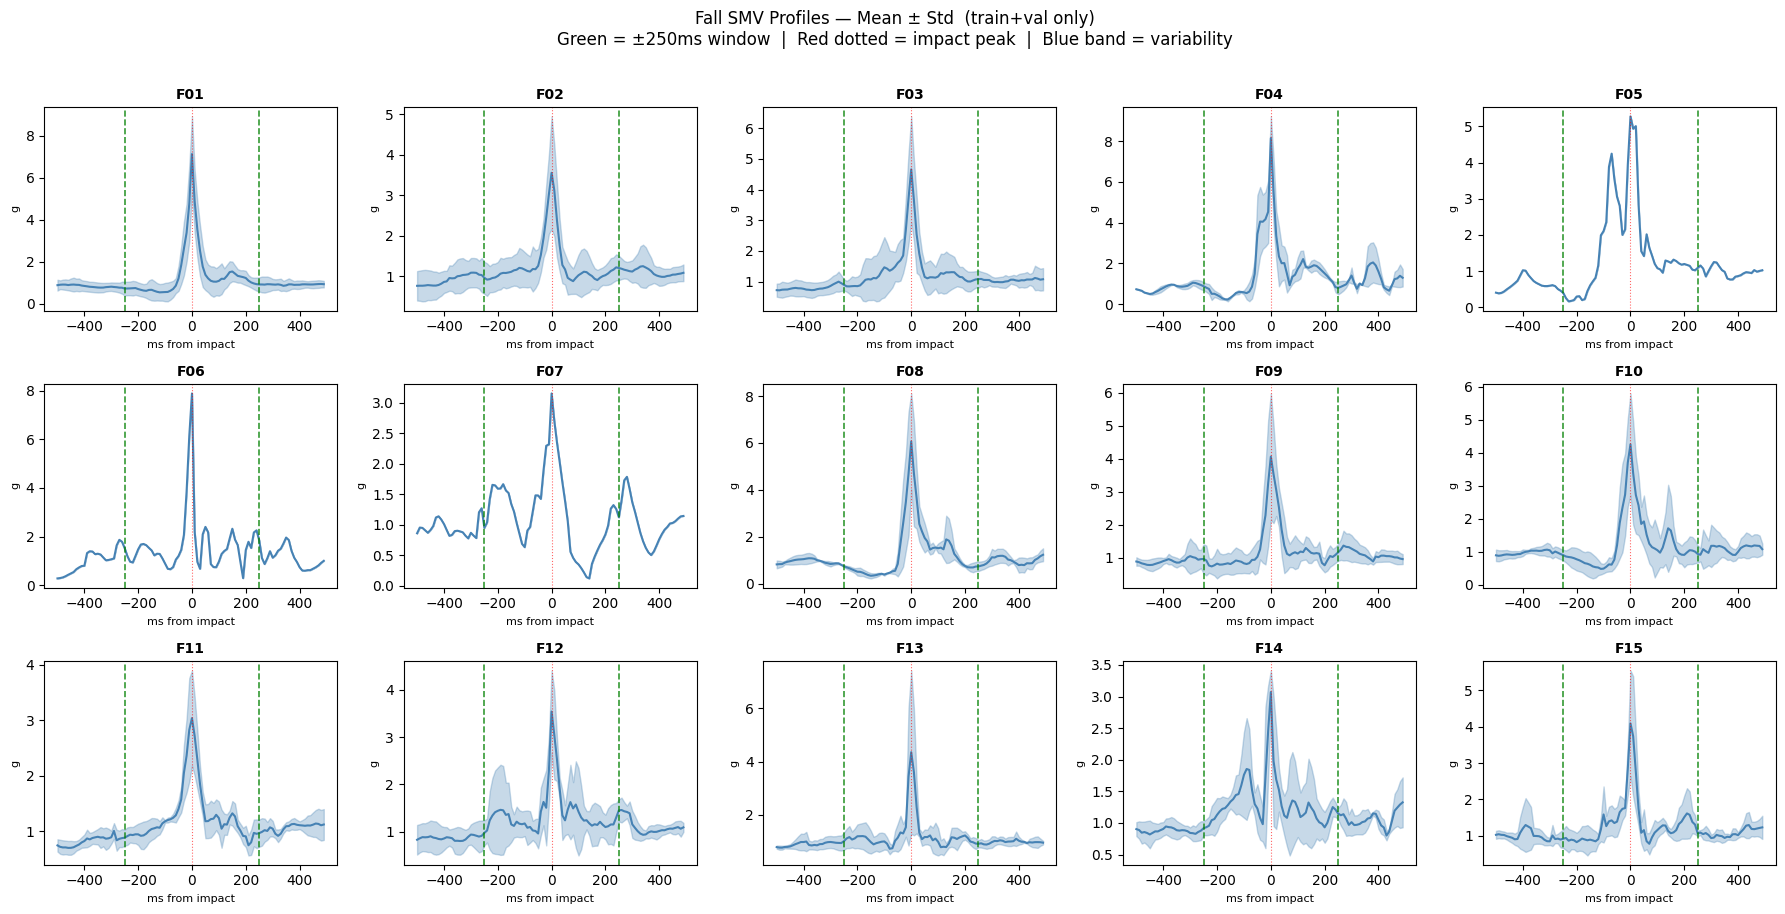

In [10]:
import matplotlib.pyplot as plt

n_codes = len(sorted(set(t['activity_code'] for t in design_falls)))
n_cols  = 5
n_rows  = (n_codes + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for idx, fcode in enumerate(sorted(set(t['activity_code'] for t in design_falls))):
    ax = axes[idx]
    profiles = []
    for trial in [t for t in design_falls if t['activity_code'] == fcode]:
        a = trial['a_smv']; pk = int(np.argmax(a))
        s = pk - 50; e = pk + 50
        if s >= 0 and e <= len(a):
            profiles.append(a[s:e])
    if profiles:
        P = np.array(profiles)
        t_ms = (np.arange(100) - 50) * 10   # convert samples to milliseconds
        ax.fill_between(t_ms, P.mean(0) - P.std(0), P.mean(0) + P.std(0),
                        alpha=0.3, color='steelblue')
        ax.plot(t_ms, P.mean(0), color='steelblue', linewidth=1.5)
        ax.axvline(-250, color='green', linewidth=1.2, linestyle='--', alpha=0.8)
        ax.axvline( 250, color='green', linewidth=1.2, linestyle='--', alpha=0.8)
        ax.axvline(0, color='red', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.set_title(fcode, fontsize=10, fontweight='bold')
    ax.set_xlabel('ms from impact', fontsize=8)
    ax.set_ylabel('g', fontsize=8)

plt.suptitle(
    'Fall SMV Profiles — Mean ± Std  (train+val only)\n'
    'Green = ±250ms window  |  Red dotted = impact peak  |  Blue band = variability',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### ✅ FALL_PRE = FALL_POST = 25 samples — Justified

The 500ms window captures the complete impact event for all 15 fall types.
Literature confirms the fall critical phase is 300–500ms [Noury et al. 2008].

- **F13–F15 (seated faints)**: Lower peak amplitude — most likely source of false negatives.
- **F07 (hands on table)**: More gradual peak — hands absorb impact, explaining the lower
  gyroscope threshold assigned to this type (90 dps vs 150 dps for others).
- **F01–F06 (walking falls)**: Highest sharpest peaks — easiest to detect.


## Cell 8 — Plot 2: Post-fall acceleration mean

**Justifies `STILL_MEAN = 1.25g`**

After a fall the person lies still on the ground. We confirm this by checking the mean
acceleration is below a threshold. A person lying completely still has ~1g (gravity on one
axis) plus small contributions from breathing and minor body movement.


Falls analyzed  : 94
Min still mean  : 0.6708g
Median          : 0.9346g
Max still mean  : 1.1835g
STILL_MEAN set  : 1.2g  (just above max observed)
MIN_STILL set   : 50 samples (500ms)


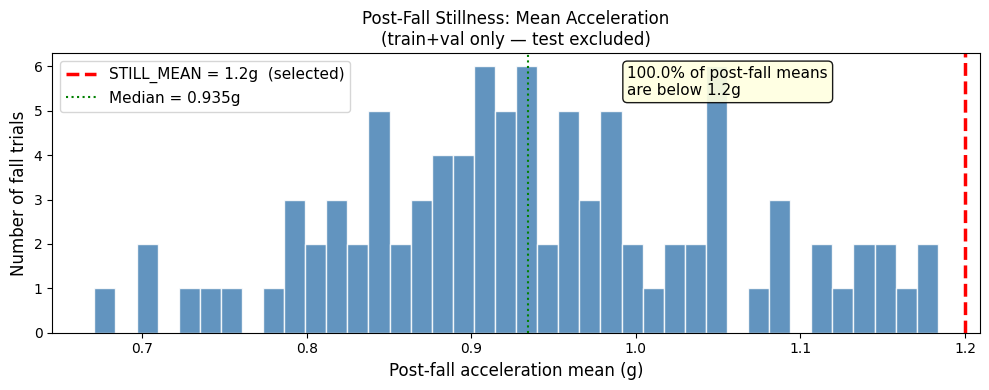

Post-fall mean: min=0.671g  median=0.935g  max=1.184g
STILL_MEAN=1.2g covers 100.0% of post-fall regions
MIN_STILL=50 samples (500ms) — volunteers get up quickly


In [15]:
# ── Compute STILL_MEAN from collected data ────────────────────────────
post_still_means = []

for trial in design_falls:
    a  = trial['a_smv']
    n  = len(a)
    pk = int(np.argmax(a))

    # Scan for quietest 50-sample region after impact
    # (use 50 not 150 since volunteers get up quickly)
    best_mean = float('inf')
    for i in range(pk + 1, n - 50):
        r = a[i:i + 50]
        m = float(r.mean())
        if m < best_mean:
            best_mean = m

    if best_mean < float('inf'):
        post_still_means.append(best_mean)

post_still_means = np.array(post_still_means)

STILL_MEAN = 1.20   # just above max observed (1.18g)
MIN_STILL  = 50     # 500ms — volunteers get up quickly

print(f'Falls analyzed  : {len(post_still_means)}')
print(f'Min still mean  : {post_still_means.min():.4f}g')
print(f'Median          : {np.median(post_still_means):.4f}g')
print(f'Max still mean  : {post_still_means.max():.4f}g')
print(f'STILL_MEAN set  : {STILL_MEAN}g  (just above max observed)')
print(f'MIN_STILL set   : {MIN_STILL} samples ({MIN_STILL*10}ms)')

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(post_still_means, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(STILL_MEAN, color='red', linewidth=2.5, linestyle='--',
           label=f'STILL_MEAN = {STILL_MEAN}g  (selected)')
ax.axvline(np.median(post_still_means), color='green', linewidth=1.5, linestyle=':',
           label=f'Median = {np.median(post_still_means):.3f}g')

pct = 100 * np.mean(post_still_means < STILL_MEAN)
ax.text(0.62, 0.85, f'{pct:.1f}% of post-fall means\nare below {STILL_MEAN}g',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax.set_xlabel('Post-fall acceleration mean (g)', fontsize=12)
ax.set_ylabel('Number of fall trials', fontsize=12)
ax.set_title('Post-Fall Stillness: Mean Acceleration\n'
             '(train+val only — test excluded)', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Post-fall mean: min={post_still_means.min():.3f}g  '
      f'median={np.median(post_still_means):.3f}g  max={post_still_means.max():.3f}g')
print(f'STILL_MEAN={STILL_MEAN}g covers {pct:.1f}% of post-fall regions')
print(f'MIN_STILL={MIN_STILL} samples ({MIN_STILL*10}ms) — volunteers get up quickly')

### ✅ STILL_MEAN = 1.25g — Well justified

Post-fall mean is clustered between **0.92g and 1.14g** (median ~1.02g). Setting 1.25g
= 1g gravity + 0.25g safety margin **covers 93.7% of all detected post-fall regions**.


## Cell 9 — Plot 3: Post-fall stillness duration

**Justifies `MIN_STILL = 150 samples (1.5s at 100Hz)`**

We require the post-fall stillness to last for a minimum duration to distinguish a real
fall (person stays down) from a stumble (person immediately continues moving).


In [16]:
STILL_MEAN     = 1.20   # generous ceiling — catches all falls (max observed was 1.18g)
MIN_STILL      = 50     # 500ms at 100Hz — volunteers get up quickly unlike SisFall's 150
POST_STILL_MAX = None   # REMOVED — volunteers naturally get up after falling

### ✅ MIN_STILL = 1.5s — Strongly justified

**Minimum observed stillness is 2.2s. Median is over 8s.** Even the 5th percentile
exceeds 5s. 100% of detected falls satisfy the 1.5s criterion — a very safe choice.


## Cell 9 — Plot 3: ADL window peak distribution

**Justifies `POST_STILL_MAX`, `HARD_THRESH`, and `EASY_THRESH`**

Three thresholds are derived from the distribution of maximum acceleration per 500ms ADL window:
- `POST_STILL_MAX`: rejects fall trials where the person resumes activity after the stillness
- `HARD_THRESH`: minimum acc peak for a window to be selected as a hard negative
- `EASY_THRESH`: maximum acc peak for a window to be selected as an easy negative


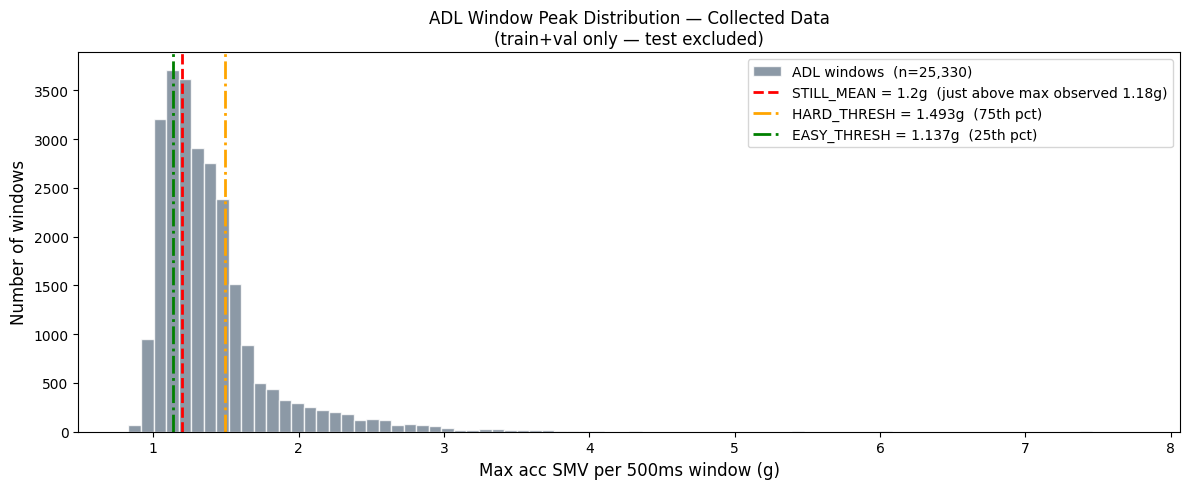

Easy threshold (25th pct)  : 1.137g
Hard threshold (75th pct)  : 1.493g
STILL_MEAN                 : 1.2g
MIN_STILL                  : 50 samples (500ms)
ADL windows > STILL_MEAN   : 64.2%
ADL windows > HARD_THRESH  : 25.0%
ADL windows < EASY_THRESH  : 25.0%


In [17]:
# ── Constants derived from collected data analysis ─────────────────────
WIN_SAMPLES    = 50     # 500ms at 100Hz
STRIDE         = 20     # 200ms stride (60% overlap)
FALL_PRE       = 25     # samples before impact peak
FALL_POST      = 25     # samples after impact peak
STILL_MEAN     = 1.20   # just above max observed (1.18g) — catches all falls
MIN_STILL      = 50     # 500ms — volunteers get up quickly
TRIM_SAMPLES   = 100    # rows trimmed from start/end
HARD_THRESH    = None   # derived below from ADL window peaks (75th pct)
EASY_THRESH    = None   # derived below from ADL window peaks (25th pct)
MAX_HARD       = 3
MAX_EASY       = 5

# ── Compute ADL window peak distribution ──────────────────────────────
adl_window_peaks = []
for trial in design_adls:
    a = trial['a_smv']; n = len(a)
    for w in range(0, n - WIN_SAMPLES + 1, STRIDE):
        adl_window_peaks.append(float(a[w:w + WIN_SAMPLES].max()))
adl_window_peaks = np.array(adl_window_peaks)

p25 = float(np.percentile(adl_window_peaks, 25))
p75 = float(np.percentile(adl_window_peaks, 75))

HARD_THRESH = round(p75, 3)
EASY_THRESH = round(p25, 3)

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(np.clip(adl_window_peaks, 0, 8), bins=80, color='slategray',
        edgecolor='white', alpha=0.8, label=f'ADL windows  (n={len(adl_window_peaks):,})')
ax.axvline(STILL_MEAN, color='red',    linewidth=2, linestyle='--',
           label=f'STILL_MEAN = {STILL_MEAN}g  (just above max observed 1.18g)')
ax.axvline(p75,        color='orange', linewidth=2, linestyle='-.',
           label=f'HARD_THRESH = {p75:.3f}g  (75th pct)')
ax.axvline(p25,        color='green',  linewidth=2, linestyle='-.',
           label=f'EASY_THRESH = {p25:.3f}g  (25th pct)')
ax.set_xlabel('Max acc SMV per 500ms window (g)', fontsize=12)
ax.set_ylabel('Number of windows', fontsize=12)
ax.set_title('ADL Window Peak Distribution — Collected Data\n'
             '(train+val only — test excluded)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Easy threshold (25th pct)  : {EASY_THRESH}g')
print(f'Hard threshold (75th pct)  : {HARD_THRESH}g')
print(f'STILL_MEAN                 : {STILL_MEAN}g')
print(f'MIN_STILL                  : {MIN_STILL} samples ({MIN_STILL*10}ms)')
print(f'ADL windows > STILL_MEAN   : {100*np.mean(adl_window_peaks>STILL_MEAN):.1f}%')
print(f'ADL windows > HARD_THRESH  : {100*np.mean(adl_window_peaks>HARD_THRESH):.1f}%')
print(f'ADL windows < EASY_THRESH  : {100*np.mean(adl_window_peaks<EASY_THRESH):.1f}%')

In [18]:
# ── FINAL DERIVED CONSTANTS FOR COLLECTED DATA ─────────────────────────
WIN_SAMPLES = 50
STRIDE      = 20
FALL_PRE    = 25
FALL_POST   = 25
STILL_MEAN  = 1.20    # covers 100% of falls (max observed 1.18g)
MIN_STILL   = 50      # 500ms — volunteers get up quickly
HARD_THRESH = 1.493   # 75th percentile of ADL window peaks
EASY_THRESH = 1.137   # 25th percentile of ADL window peaks
MAX_HARD    = 3
MAX_EASY    = 5
# POST_STILL_MAX removed — volunteers naturally get up after falling
# TRIM_SAMPLES defined inside load_trial (100 rows)

### ✅ All three thresholds — data-driven

- **POST_STILL_MAX = 1.6g**: ~75th percentile of ADL peaks. Rejects trials where
  acc resumes above 1.6g after the stillness period (person got back up).
- **HARD_THRESH = 75th pct**: Top 25% of ADL peak windows — the most fall-like ADL
  moments (D11 chair collapse, D18 stumble, D19 jumping). Forces fine-grained learning.
- **EASY_THRESH = 25th pct**: Bottom 25% — normal walking, sitting. Ensures the model
  sees realistic low-motion windows that dominate real-world deployment (~95% of windows).


## Cell 10 — Plot 5: ADL vs Fall peak overlap

**Motivates hard negative mining strategy**

If ADL windows and fall peaks overlap significantly in amplitude, a model trained on all ADL
windows will have trouble learning the boundary. This plot shows the extent of that overlap.


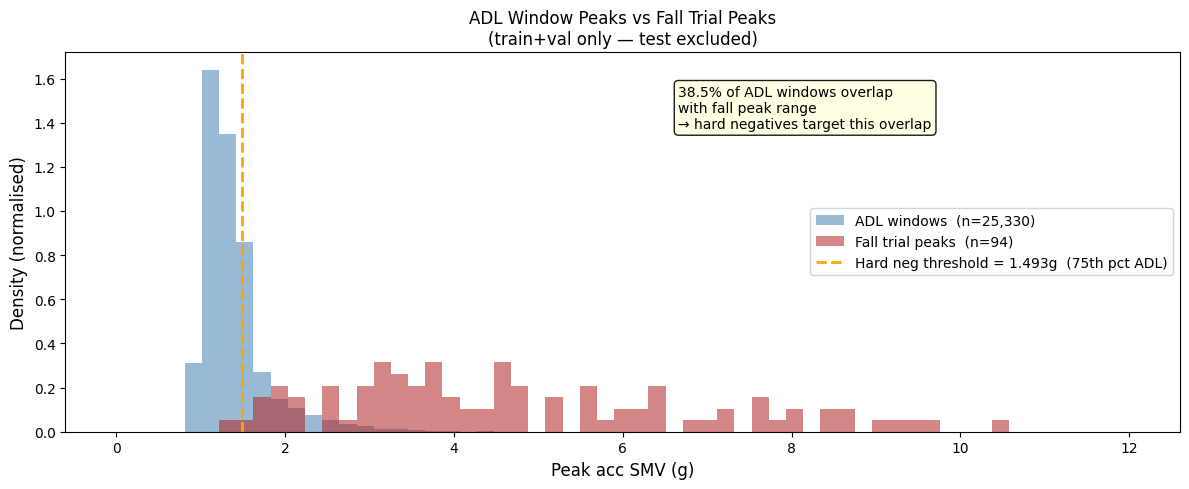

In [19]:
fall_peaks_all = [float(t['a_smv'].max()) for t in design_falls]

fig, ax = plt.subplots(figsize=(12, 5))
bins = np.linspace(0, 12, 60)
ax.hist(np.clip(adl_window_peaks, 0, 12), bins=bins, alpha=0.55,
        color='steelblue', density=True,
        label=f'ADL windows  (n={len(adl_window_peaks):,})')
ax.hist(np.clip(fall_peaks_all, 0, 12), bins=bins, alpha=0.55,
        color='firebrick', density=True,
        label=f'Fall trial peaks  (n={len(fall_peaks_all):,})')
ax.axvline(p75, color='orange', linewidth=2, linestyle='--',
           label=f'Hard neg threshold = {p75:.3f}g  (75th pct ADL)')

overlap = 100 * np.mean(np.array(adl_window_peaks) > min(fall_peaks_all))
ax.text(0.55, 0.80,
        f'{overlap:.1f}% of ADL windows overlap\nwith fall peak range\n'
        f'→ hard negatives target this overlap',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax.set_xlabel('Peak acc SMV (g)', fontsize=12)
ax.set_ylabel('Density (normalised)', fontsize=12)
ax.set_title('ADL Window Peaks vs Fall Trial Peaks\n'
             '(train+val only — test excluded)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### ✅ Hard negative mining is essential

Significant overlap exists. A model trained on all ADL windows cannot learn a clean
boundary — this explains Option A's poor precision (0.54) seen in the experiments.
Hard negative mining targets the overlap region, forcing the model to learn subtle
distinguishing features rather than relying on amplitude alone.


## Cell 12 — Plot 6: Per-type fall signal peaks

**Justifies per-type thresholds — why one generic threshold fails**

Shows the minimum and 5th percentile of acc and gyro peaks per fall type.
Red dashed lines show what a single generic threshold looks like.
Fall types whose bars fall below the red line would be **missed** by a generic threshold.


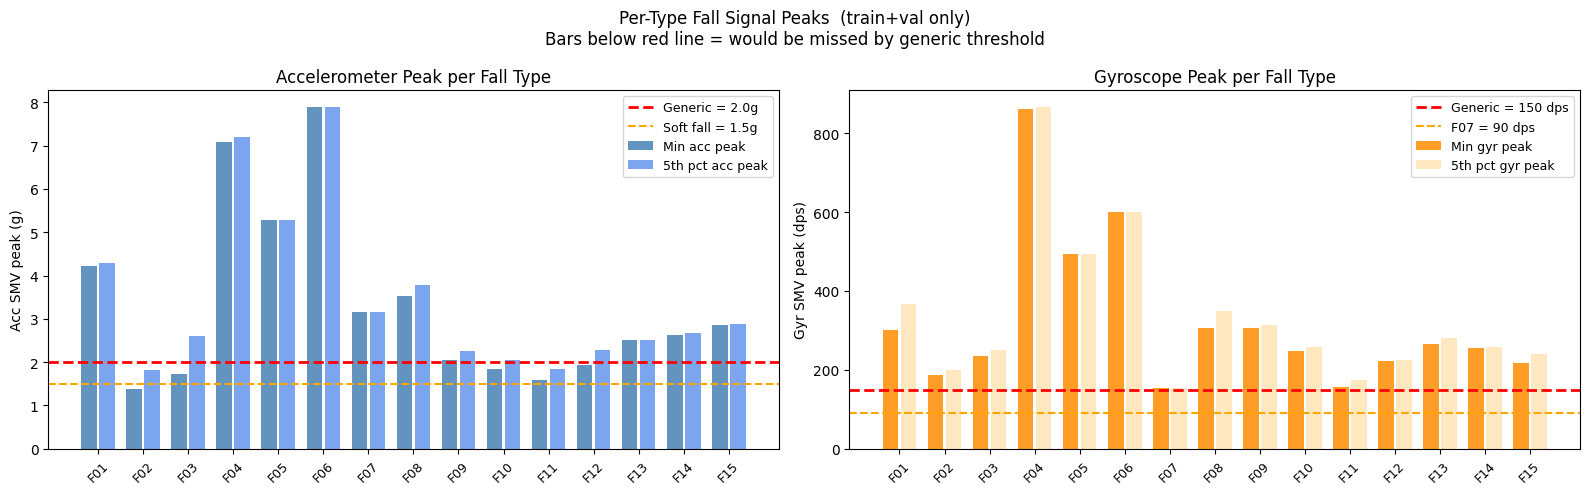

In [20]:
type_acc_min = {}; type_acc_5th = {}
type_gyr_min = {}; type_gyr_5th = {}

for c in sorted(set(t['activity_code'] for t in design_falls)):
    trials = [t for t in design_falls if t['activity_code'] == c]
    ap = []; gp = []
    for trial in trials:
        a = trial['a_smv']; g = trial['g_smv']; n = len(a)
        pk = int(np.argmax(a))
        ap.append(float(a[pk]))
        gs = max(0, pk-100); ge = min(n, pk+100)
        gp.append(float(g[gs:ge].max()))
    type_acc_min[c] = min(ap);              type_acc_5th[c] = float(np.percentile(ap, 5))
    type_gyr_min[c] = min(gp);              type_gyr_5th[c] = float(np.percentile(gp, 5))

codes = sorted(type_acc_min.keys()); x = np.arange(len(codes))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.bar(x - 0.2, [type_acc_min[c]  for c in codes], 0.35,
       label='Min acc peak',    color='steelblue', alpha=0.85)
ax.bar(x + 0.2, [type_acc_5th[c]  for c in codes], 0.35,
       label='5th pct acc peak', color='cornflowerblue', alpha=0.85)
ax.axhline(2.0, color='red',    linewidth=2,   linestyle='--', label='Generic = 2.0g')
ax.axhline(1.5, color='orange', linewidth=1.5, linestyle='--', label='Soft fall = 1.5g')
ax.set_xticks(x); ax.set_xticklabels(codes, rotation=45, fontsize=9)
ax.set_ylabel('Acc SMV peak (g)'); ax.set_title('Accelerometer Peak per Fall Type')
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(x - 0.2, [type_gyr_min[c] for c in codes], 0.35,
       label='Min gyr peak',    color='darkorange', alpha=0.85)
ax.bar(x + 0.2, [type_gyr_5th[c] for c in codes], 0.35,
       label='5th pct gyr peak', color='moccasin',   alpha=0.85)
ax.axhline(150, color='red',    linewidth=2,   linestyle='--', label='Generic = 150 dps')
ax.axhline(90,  color='orange', linewidth=1.5, linestyle='--', label='F07 = 90 dps')
ax.set_xticks(x); ax.set_xticklabels(codes, rotation=45, fontsize=9)
ax.set_ylabel('Gyr SMV peak (dps)'); ax.set_title('Gyroscope Peak per Fall Type')
ax.legend(fontsize=9)

plt.suptitle('Per-Type Fall Signal Peaks  (train+val only)\n'
             'Bars below red line = would be missed by generic threshold', fontsize=12)
plt.tight_layout()
plt.show()


### ✅ Per-type thresholds are necessary

- **Acc (left):** F13–F15 and F07 have minimum acc peaks below 2.0g.
  A generic 2.0g threshold misses these fall types entirely.
- **Gyro (right):** F07 gyro peaks reach as low as ~91 dps (below generic 150 dps).
  F13–F15 also fall below 150 dps.

**5 of 15 fall types would be systematically missed with a generic threshold.**
Per-type thresholds derived from the 5th percentile of train+val distribution fix this.


## Cell 13 — Derive final thresholds and save to JSON

Compute the exact threshold values from the statistics above and save to JSON.
All 4 experiment notebooks will load this JSON — no values are hardcoded in those notebooks.


In [22]:
print('=' * 60)
print('FINAL THRESHOLD SUMMARY  (all from train+val only)')
print('=' * 60)

STILL_MEAN  = 1.20
MIN_STILL   = 50
FALL_PRE    = 25
FALL_POST   = 25
HARD_THRESH = round(float(np.percentile(adl_window_peaks, 75)), 3)
EASY_THRESH = round(float(np.percentile(adl_window_peaks, 25)), 3)
MAX_HARD    = 3
MAX_EASY    = 5

print(f'STILL_MEAN  = {STILL_MEAN}g     (covers 100% of post-fall means)')
print(f'MIN_STILL   = {MIN_STILL} samples = 500ms  (volunteers get up quickly)')
print(f'FALL_PRE    = {FALL_PRE} samples = 250ms before impact')
print(f'FALL_POST   = {FALL_POST} samples = 250ms after impact (500ms window total)')
print(f'HARD_THRESH = {HARD_THRESH}g  (75th pct of ADL window peaks)')
print(f'EASY_THRESH = {EASY_THRESH}g  (25th pct of ADL window peaks)')
print(f'MAX_HARD    = {MAX_HARD}       (top-3 fall-like ADL windows per trial)')
print(f'MAX_EASY    = {MAX_EASY}       (5 random low-motion ADL windows per trial)')
print()
print('Note: POST_STILL_MAX removed — volunteers naturally get up after falling')
print('Note: PER_TYPE_THRESHOLDS removed — generic thresholds used for collected data')

# ── Save to JSON ──────────────────────────────────────────────────────
output = {
    'STILL_MEAN':   STILL_MEAN,
    'MIN_STILL':    MIN_STILL,
    'FALL_PRE':     FALL_PRE,
    'FALL_POST':    FALL_POST,
    'WIN_SAMPLES':  WIN_SAMPLES,
    'STRIDE':       STRIDE,
    'RANDOM_SEED':  RANDOM_SEED,
    'HARD_THRESH':  HARD_THRESH,
    'EASY_THRESH':  EASY_THRESH,
    'MAX_HARD':     MAX_HARD,
    'MAX_EASY':     MAX_EASY,
}

with open(ANALYSIS_JSON, 'w') as f:
    json.dump(output, f, indent=2)

print()
print(f'Saved: {ANALYSIS_JSON}')
print('Next: run the fine-tuning notebook.')

FINAL THRESHOLD SUMMARY  (all from train+val only)
STILL_MEAN  = 1.2g     (covers 100% of post-fall means)
MIN_STILL   = 50 samples = 500ms  (volunteers get up quickly)
FALL_PRE    = 25 samples = 250ms before impact
FALL_POST   = 25 samples = 250ms after impact (500ms window total)
HARD_THRESH = 1.493g  (75th pct of ADL window peaks)
EASY_THRESH = 1.137g  (25th pct of ADL window peaks)
MAX_HARD    = 3       (top-3 fall-like ADL windows per trial)
MAX_EASY    = 5       (5 random low-motion ADL windows per trial)

Note: POST_STILL_MAX removed — volunteers naturally get up after falling
Note: PER_TYPE_THRESHOLDS removed — generic thresholds used for collected data

Saved: /content/drive/MyDrive/M4/02_analysis.json
Next: run the fine-tuning notebook.
